# Customer Churn Prediction 

The process includes:
1.  **Data Loading & Inspection**: Getting the data ready.
2.  **Data Cleaning & Preprocessing**: Handling missing values and encoding categorical features.
3.  **Exploratory Data Analysis (EDA)**: Visualizing the data to find patterns.
4.  **Model Preparation**: Splitting and scaling the data.
5.  **Model Training & Evaluation**: Building and testing several core classification models.

--- 
### 1. Import Essential Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score)

import warnings
warnings.filterwarnings('ignore')

--- 
### 2. Load and Inspect the Data

In [5]:
churn_df = pd.read_csv(r"C:\Users\simar\Desktop\Churn Predictor\Scripts\churn_data.csv")
print("--- Initial Data ---")
churn_df.head(3)

--- Initial Data ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


--- 
### 3. Data Cleaning and Preprocessing

In [7]:
# customerID is of no use in this case and has no meaningful value in model making
churn_df = churn_df.drop("customerID", axis=1)

# To check and convert emoty strings to actual NaN (Not a Number) values.
churn_df['TotalCharges'] = pd.to_numeric(churn_df['TotalCharges'], errors='coerce')

# Using front fill to fill NaN values
churn_df['TotalCharges'] = churn_df['TotalCharges'].ffill()

"Data cleaned successfully!"

'Data cleaned successfully!'

#### Encoding Categorical Features
Machine learning models require all input features to be numerical. We will convert all text-based categorical columns into numbers using `LabelEncoder`.

In [9]:
# Identify all columns that are categorical (of type 'object')
categorical_features = [col for col in churn_df.columns if churn_df[col].dtype == 'object']

# Use LabelEncoder to convert each categorical column into numbers including churn.
for col in categorical_features:
    encoder = LabelEncoder()
    churn_df[col] = encoder.fit_transform(churn_df[col])

print("--- Preprocessed Data with Encoded Features ---")
churn_df.head()

--- Preprocessed Data with Encoded Features ---


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


--- 
### 4. Exploratory Data Analysis (EDA)

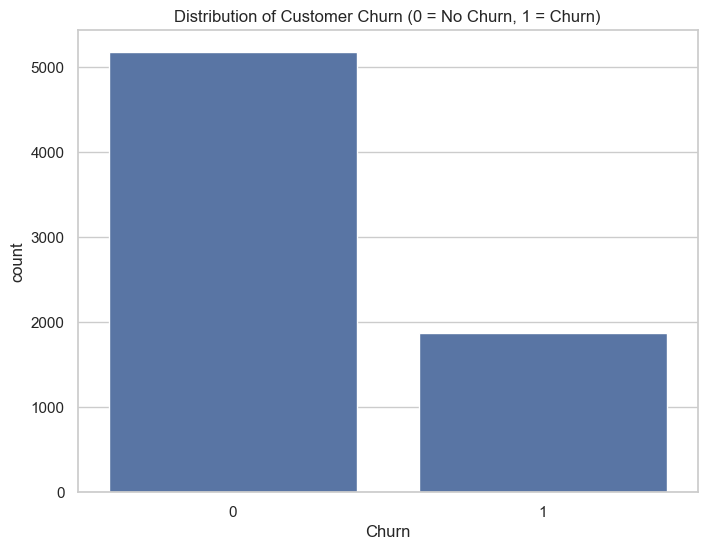

In [32]:
sns.set(style="whitegrid")

# Create a count plot to see the distribution of Churn vs. No Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=churn_df)
plt.title('Distribution of Customer Churn (0 = No Churn, 1 = Churn)')
plt.show()

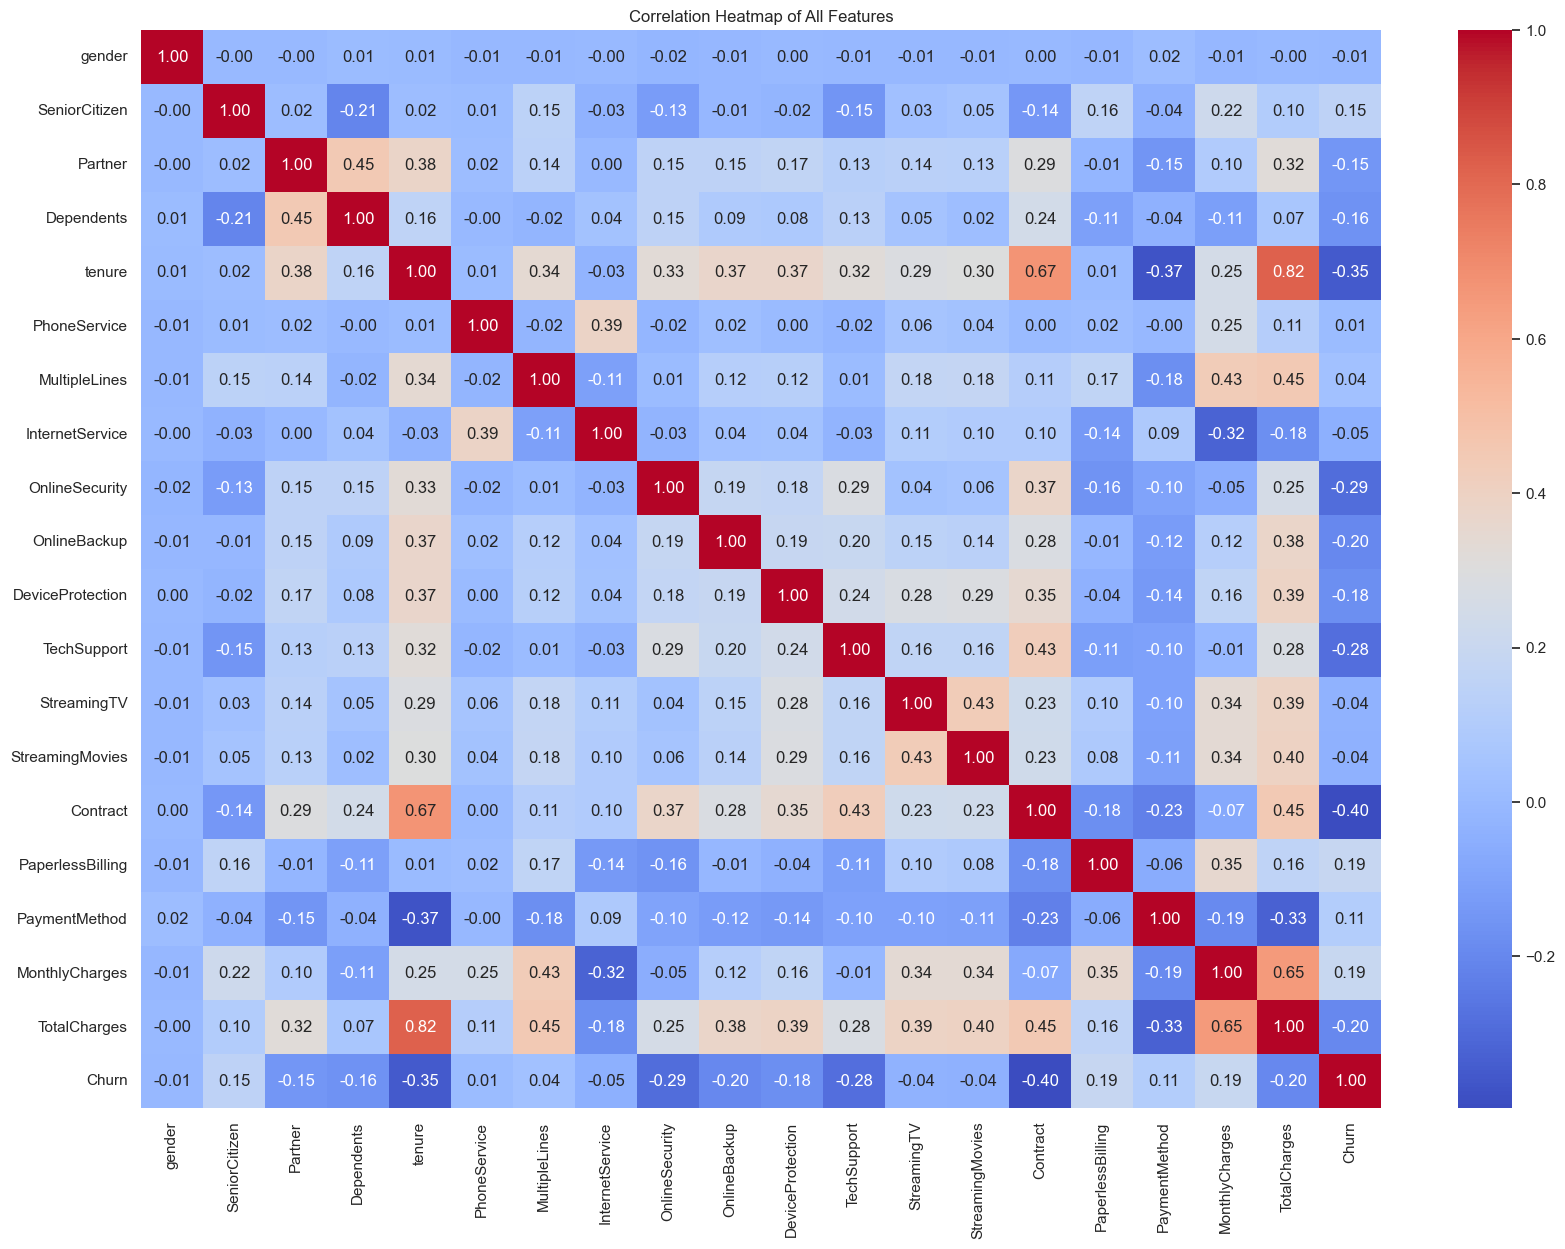

In [34]:
# Create a correlation heatmap to see how features relate to each other and to the Churn variable
plt.figure(figsize=(20, 14))
sns.heatmap(churn_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of All Features')
plt.show()

--- 
### 5. Prepare Data for Modeling

In [14]:
# Define our features (X) and the target we want to predict (y)
features = churn_df.drop('Churn', axis=1)
target = churn_df['Churn']

# Identify numerical features for scaling
numerical_features = [col for col in features.columns if churn_df[col].dtype != 'object']

# Standardize the numerical features. This brings all features to a similar scale for better accuracy.

scaler = StandardScaler()
features[numerical_features] = scaler.fit_transform(features[numerical_features])

# Train - Test split (70% : 30%)
# The `stratify` equals target equalizes the ratio of churn, no churn in both splits
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.3,
    random_state=42,
    stratify=target
)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (4930, 19)
Testing data shape: (2113, 19)


--- 
### 6. Train and Evaluate Models

In [16]:
# Dictionary for easy callouts later (nit necessary)
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True), # probability=True is needed for ROC curve
    "Decision Tree": DecisionTreeClassifier(max_depth = 5),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [17]:
# Loop through each model to train it, make predictions, and evaluate its performance
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] # Probabilities for the positive class (Churn=1)

    # Calculate performance
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Results : 
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*40 + "\n")

--- Logistic Regression ---
Accuracy: 0.8041
ROC AUC Score: 0.8426
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1552
           1       0.65      0.57      0.60       561

    accuracy                           0.80      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.80      0.80      0.80      2113



--- K-Nearest Neighbors ---
Accuracy: 0.7421
ROC AUC Score: 0.7561
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1552
           1       0.51      0.50      0.51       561

    accuracy                           0.74      2113
   macro avg       0.67      0.67      0.67      2113
weighted avg       0.74      0.74      0.74      2113



--- Support Vector Machine ---
Accuracy: 0.7932
ROC AUC Score: 0.7992
Classification Report:
              precision    recall  f1-score   support

           0  

# Code Ends Here
